# 4.1 — Modèles sensibles à l'échelle

Cette famille regroupe les modèles dont la fonction objectif ou la métrique de similarité dépend de l'**échelle** des features — donc **tous** doivent recevoir des données normalisées (`preprocessor_scaled`).

| Modèle           | Hypothèse principale                                                                                  |
|------------------|--------------------------------------------------------------------------------------------------------|
| OLS              | Linéarité, résidus normaux et homoscédastiques, pas de multicolinéarité parfaite                       |
| Ridge            | Idem OLS, tolère la multicolinéarité par shrinkage — features comparables en échelle indispensables   |
| Lasso            | Idem Ridge + parcimonie : suppose qu'une minorité de coefficients sont non-nuls                        |
| ElasticNet       | Compromis Ridge/Lasso                                                                                  |
| KNN              | Distance euclidienne pertinente — features comparables en échelle indispensables                       |
| MLPRegressor     | Approximation lisse par réseau de neurones — descente de gradient sensible à l'échelle                |
| SVR              | Marge ε-insensible + noyau RBF basé sur les distances — mise à l'échelle obligatoire                   |

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
Variables après ingénierie : 90 colonnes (+8 dérivées)
Corrélation des variables dérivées avec SalePrice_log :
  TotalSF            : +0.825
  TotalBathrooms     : +0.677
  HouseAge           : -0.588
  YearsSinceRemodel  : -0.569
  GarageAge          : -0.543
  HasGarage          : +0.323
  HasSecondFloor     : +0.151
  HasPool            : +0.077   <-- faible (|r| < 0.1)
X_train : (1166, 83)   |   X_test : (292, 83)
Colonnes retirées (colinéarité) : ['GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd', 'GarageYrBlt']
NaN dans X_train : 6276 cellules sur 96778
Audit de cardinalité des colonnes nominales (sur X_train) :
Colonne           modalités   bucket
  Neighborhood           25     TargetEncoder (haute)  [imput. mode]
  Exterior2nd            16     TargetEncoder (haute)  [imput. mode]
  Exterior1st            15     TargetEncoder (haute)  [imput. mode]
  MSSubClass             15     

In [2]:
from app.optuna_tuning import tune_xgb_pipeline, tune_mlp_pipeline, tune_svr_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

FAMILY = 'scaled'


C:\PROG_DataScience\DataScienceProject\predicting-house-prices-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1.1 OLS (régression linéaire ordinaire) — baseline

### Hypothèses du modèle
1. **Linéarité** entre les features et `y_log` — vérifiable par les résidus-vs-fitted.
2. **Indépendance** des erreurs — vérifiable par Durbin-Watson.
3. **Homoscédasticité** (variance constante des résidus) — vérifiable par scale-location + Breusch-Pagan.
4. **Normalité** des résidus — vérifiable par Q-Q plot + Jarque-Bera.
5. **Pas de multicolinéarité parfaite** — partiellement adressée par le retrait prévu des features redondantes (`GarageArea`/`TotalBsmtSF`/`TotRmsAbvGrd`/`GarageYrBlt`).

**Préprocesseur** : `preprocessor_scaled` — OLS n'a pas strictement besoin de la mise à l'échelle (les coefficients absorbent l'unité), mais on l'inclut pour cohérence et meilleure stabilité numérique.

OLS — CV RMSLE: 0.1205   Holdout RMSLE: 0.1164   fit_time: 0.30s


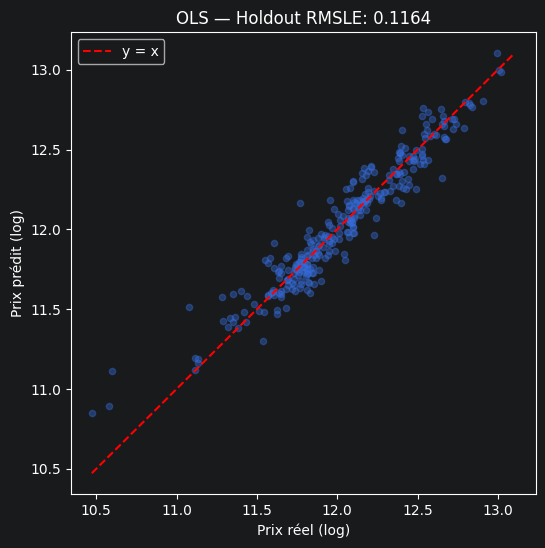

WindowsPath('results/family_scaled.json')

In [3]:
t0 = time.time()
ols_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LinearRegression()),
])
ols_pipe.fit(X_train, y_train_log)
ols_fit_s = time.time() - t0

ols_pred_log = ols_pipe.predict(X_test)
ols_holdout = rmsle_score(y_test_log, ols_pred_log)
ols_cv = cv_rmsle(ols_pipe, X_train, y_train_log)

print(f"OLS — CV RMSLE: {ols_cv:.4f}   Holdout RMSLE: {ols_holdout:.4f}   fit_time: {ols_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ols_pred_log, title=f"OLS — Holdout RMSLE: {ols_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'OLS', cv_rmsle=ols_cv, holdout_rmsle=ols_holdout, fit_time_s=ols_fit_s)

### Diagnostic des hypothèses OLS

On ajuste une régression `statsmodels` sur les mêmes features transformées (le préprocesseur est déjà ajusté sur `X_train` — pas de fuite) pour obtenir le **résumé complet** `sm.OLS().summary()` : table des coefficients **et** bloc de diagnostics (Durbin-Watson, Omnibus, Jarque-Bera, Cond. No.). On le complète par le test de **Breusch-Pagan** (homoscédasticité, absent du résumé par défaut) et trois graphiques :

- **Linéarité** → résidus vs valeurs ajustées (nuage centré sur 0, sans structure).
- **Indépendance** → Durbin-Watson (≈ 2 attendu, lu dans le résumé).
- **Homoscédasticité** → scale-location + Breusch-Pagan.
- **Normalité des résidus** → Q-Q plot (`sm.qqplot`) + Jarque-Bera (lu dans le résumé).

In [4]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Le préprocesseur du pipeline OLS est déjà ajusté sur X_train -> on réutilise sa transformation (pas de fuite)
prep_fitted = ols_pipe.named_steps['preprocessor']
X_train_t = prep_fitted.transform(X_train)
X_train_t = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else np.asarray(X_train_t)
feat_names = prep_fitted.get_feature_names_out()

X_sm = sm.add_constant(pd.DataFrame(X_train_t, columns=feat_names, index=X_train.index))
ols_sm = sm.OLS(y_train_log.values, X_sm).fit()

# Résumé complet : coefficients + bloc diagnostics (Durbin-Watson, Omnibus, Jarque-Bera, Cond. No.)
print(ols_sm.summary())

# Homoscédasticité : Breusch-Pagan (absent du résumé statsmodels par défaut)
bp_lm, bp_p, _, _ = het_breuschpagan(ols_sm.resid, X_sm)
print(f"\nBreusch-Pagan (homoscédasticité) : LM={bp_lm:.1f}, p={bp_p:.2e}   (p < 0.05 -> hétéroscédasticité)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     140.2
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:26:03   Log-Likelihood:                 1009.0
No. Observations:                1166   AIC:                            -1802.
Df Residuals:                    1058   BIC:                            -1255.
Df Model:                         107                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

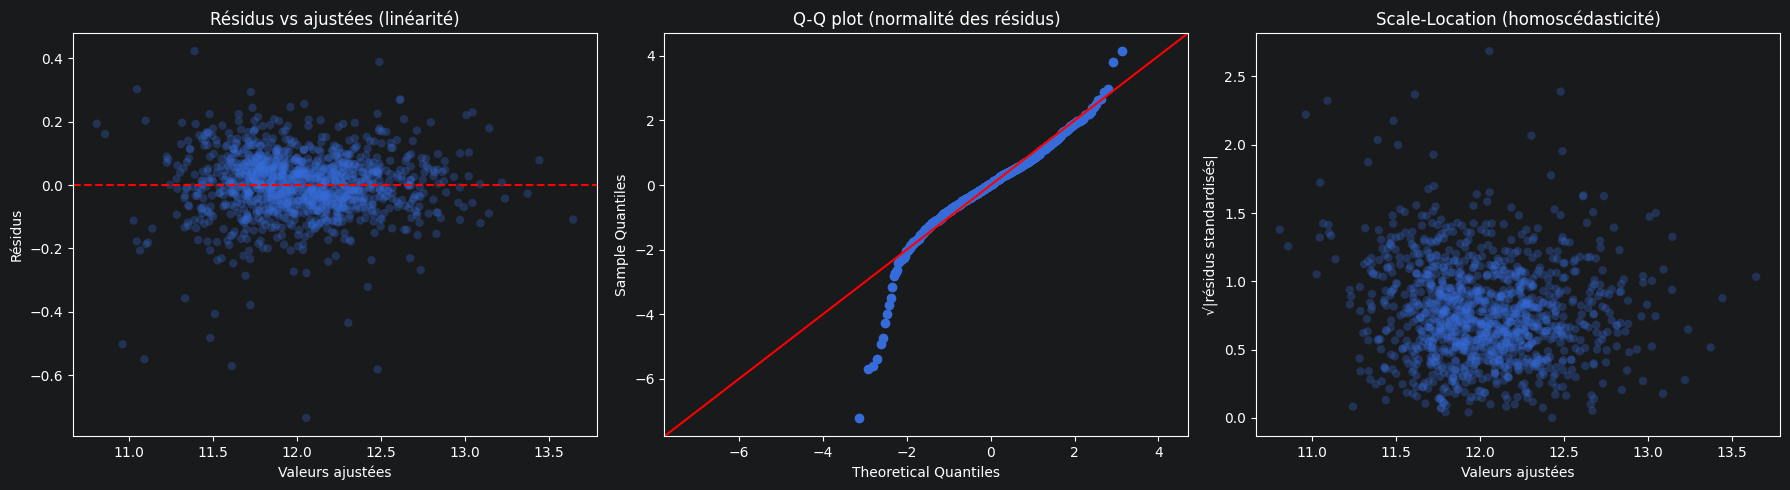

In [5]:
# Graphiques de diagnostic sur les résidus d'entraînement
resid = ols_sm.resid
fitted = ols_sm.fittedvalues
std_resid = resid / resid.std(ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted, resid, alpha=0.3, edgecolor='none')
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Valeurs ajustées', ylabel='Résidus', title='Résidus vs ajustées (linéarité)')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot (normalité des résidus)')
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, edgecolor='none')
axes[2].set(xlabel='Valeurs ajustées', ylabel='√|résidus standardisés|', title='Scale-Location (homoscédasticité)')
plt.tight_layout()
plt.show()

**Lecture des diagnostics :**

- **Indépendance — OK.** Durbin-Watson ≈ 2.00 : aucune autocorrélation des résidus (attendu, les observations ne sont pas une série temporelle).
- **Homoscédasticité — OK.** Breusch-Pagan non significatif (p ≈ 0.51) et le scale-location reste plat : la **transformation log de la cible** a bien stabilisé la variance (sans elle, les maisons chères dominaient l'erreur absolue).
- **Normalité — VIOLÉE.** Jarque-Bera massivement significatif (p ≈ 0), skew ≈ −0.95 et kurtosis ≈ 9.6 : résidus à **queues lourdes** et légèrement asymétriques à gauche. Le Q-Q plot décroche aux extrémités → quelques biens **fortement sous-estimés** (maisons atypiques / de luxe non capturées par une relation linéaire).
- **Colinéarité — sévère.** Le nombre de conditions est gigantesque : le one-hot complet introduit le **piège des variables muettes** (colonnes linéairement dépendantes) en plus des couples redondants vus en EDA. La matrice est quasi-singulaire.

**Conséquence pédagogique :** OLS reste une **baseline** honnête (R² in-sample ≈ 0.95) mais deux hypothèses cassent — normalité et conditionnement. C'est exactement ce qui motive la suite de cette famille : **Ridge / Lasso / ElasticNet** (régularisation contre la colinéarité) puis des modèles non-linéaires robustes aux queues lourdes (familles `3b`/`3c`).

## 4.1.2 Ridge — pénalité L2

### Hypothèses du modèle
- Mêmes que OLS, mais Ridge **shrinke** les coefficients vers 0 sans en annuler aucun. Tolère la multicolinéarité (un peu) et stabilise l'estimation.
- L'hypothèse cruciale : les **features sont comparables en échelle**, sinon la pénalité L2 (somme des carrés des coefficients) frappe les features de grande amplitude davantage que les autres. → `preprocessor_scaled` est **mandatory**.

On utilise `RidgeCV` pour sélectionner automatiquement le meilleur `alpha` par cross-validation interne.

Ridge — CV RMSLE: 0.1180   Holdout RMSLE: 0.1233   alpha*: 61.58   fit_time: 0.71s


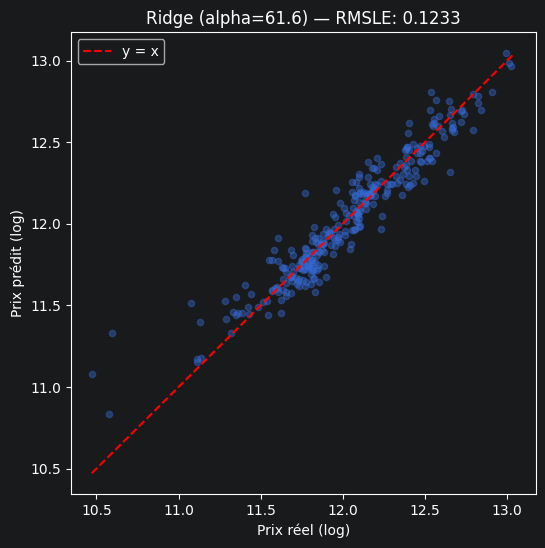

WindowsPath('results/family_scaled.json')

In [6]:
t0 = time.time()
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5)),
])
ridge_pipe.fit(X_train, y_train_log)
ridge_fit_s = time.time() - t0
ridge_alpha = ridge_pipe.named_steps['model'].alpha_

ridge_pred_log = ridge_pipe.predict(X_test)
ridge_holdout = rmsle_score(y_test_log, ridge_pred_log)
ridge_cv = cv_rmsle(ridge_pipe, X_train, y_train_log)

print(f"Ridge — CV RMSLE: {ridge_cv:.4f}   Holdout RMSLE: {ridge_holdout:.4f}   alpha*: {ridge_alpha:.4g}   fit_time: {ridge_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ridge_pred_log, title=f"Ridge (alpha={ridge_alpha:.3g}) — RMSLE: {ridge_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Ridge', cv_rmsle=ridge_cv, holdout_rmsle=ridge_holdout, fit_time_s=ridge_fit_s, params={'alpha': ridge_alpha})

## 4.1.3 Lasso — pénalité L1

### Hypothèses du modèle
- Idem Ridge, mais avec pénalité L1 (somme des **valeurs absolues**) — provoque la **sélection de variables** : certains coefficients sont mis à exactement 0.
- Hypothèse implicite : le « vrai » modèle est **parcimonieux** (la plupart des features ne contribuent pas).
- L'échelle est encore plus critique qu'avec Ridge.

Lasso — CV RMSLE: 0.1192   Holdout RMSLE: 0.1157   alpha*: 0.0004281   fit_time: 0.35s
  variables annulées : 47 / 129 (36%)


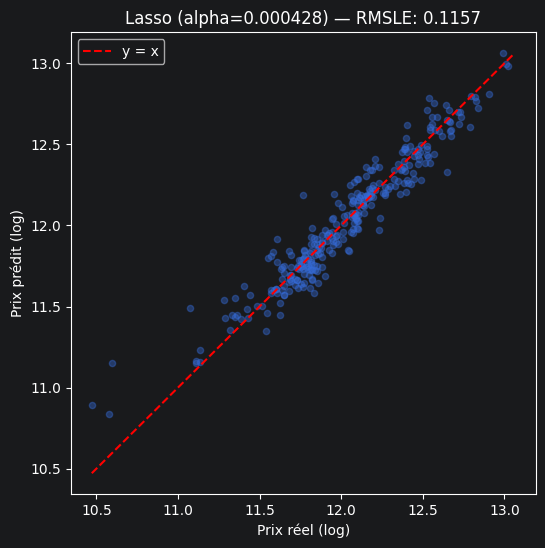

WindowsPath('results/family_scaled.json')

In [7]:
t0 = time.time()
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50_000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(X_train, y_train_log)
lasso_fit_s = time.time() - t0
lasso_alpha = lasso_pipe.named_steps['model'].alpha_

lasso_pred_log = lasso_pipe.predict(X_test)
lasso_holdout = rmsle_score(y_test_log, lasso_pred_log)
lasso_cv = cv_rmsle(lasso_pipe, X_train, y_train_log)

coefs = lasso_pipe.named_steps['model'].coef_
n_zero = int((coefs == 0).sum())
print(f"Lasso — CV RMSLE: {lasso_cv:.4f}   Holdout RMSLE: {lasso_holdout:.4f}   alpha*: {lasso_alpha:.4g}   fit_time: {lasso_fit_s:.2f}s")
print(f"  variables annulées : {n_zero} / {len(coefs)} ({100*n_zero/len(coefs):.0f}%)")
predicted_vs_actual_plot(y_test_log, lasso_pred_log, title=f"Lasso (alpha={lasso_alpha:.3g}) — RMSLE: {lasso_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Lasso', cv_rmsle=lasso_cv, holdout_rmsle=lasso_holdout, fit_time_s=lasso_fit_s,
               params={'alpha': lasso_alpha, 'n_zero_coefs': n_zero, 'n_total_coefs': len(coefs)})

## 4.1.4 ElasticNet — compromis L1 + L2

### Hypothèses du modèle
- Mélange Ridge et Lasso via le paramètre `l1_ratio`. Sélectionne des features (comme Lasso) tout en partageant la pénalité entre plusieurs features corrélées (comme Ridge).
- Pertinent quand on a des **groupes de features corrélées** — exactement notre cas (cf. NB1 : `GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`).

ElasticNet — CV RMSLE: 0.1191   Holdout RMSLE: 0.1162   alpha*: 0.0008859   l1_ratio*: 0.5   fit_time: 0.75s


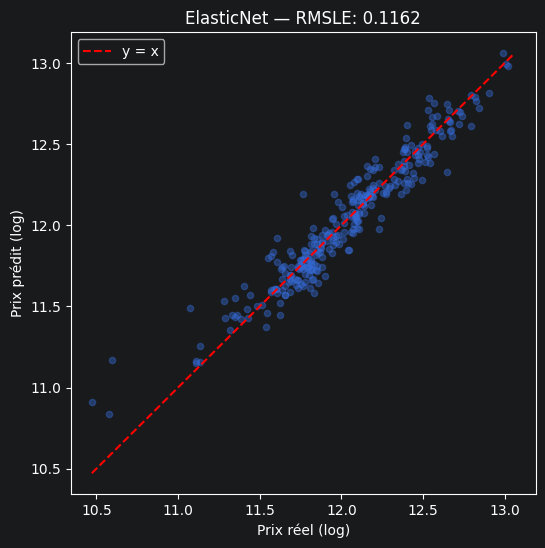

WindowsPath('results/family_scaled.json')

In [8]:
t0 = time.time()
enet_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
        alphas=np.logspace(-4, 2, 20),
        cv=5, max_iter=50_000, random_state=RANDOM_STATE,
    )),
])
enet_pipe.fit(X_train, y_train_log)
enet_fit_s = time.time() - t0
enet_alpha = enet_pipe.named_steps['model'].alpha_
enet_l1 = enet_pipe.named_steps['model'].l1_ratio_

enet_pred_log = enet_pipe.predict(X_test)
enet_holdout = rmsle_score(y_test_log, enet_pred_log)
enet_cv = cv_rmsle(enet_pipe, X_train, y_train_log)

print(f"ElasticNet — CV RMSLE: {enet_cv:.4f}   Holdout RMSLE: {enet_holdout:.4f}   alpha*: {enet_alpha:.4g}   l1_ratio*: {enet_l1}   fit_time: {enet_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, enet_pred_log, title=f"ElasticNet — RMSLE: {enet_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'ElasticNet', cv_rmsle=enet_cv, holdout_rmsle=enet_holdout, fit_time_s=enet_fit_s,
               params={'alpha': enet_alpha, 'l1_ratio': enet_l1})

### Chemins de régularisation — Ridge / Lasso / ElasticNet

Plutôt que de ne retenir que le `α*` choisi par validation croisée, on **visualise l'effet de la régularisation** : on fait varier α et on trace la trajectoire de chaque coefficient. C'est la lecture canonique de la pénalisation (cf. cours *Régularisation*) :

- **Ridge (L2)** rétrécit les coefficients **en douceur** vers 0 sans jamais les annuler ;
- **Lasso (L1)** en annule **exactement** un grand nombre → **sélection de variables** ;
- **ElasticNet** réalise un compromis entre les deux.

Le `α*` retenu par CV (sur chaque modèle) est marqué d'une ligne rouge pointillée : il situe où le modèle final se place sur la courbe de rétrécissement. On travaille sur la matrice de features standardisée (sortie de `preprocessor_scaled`), les coefficients sont donc comparables entre eux.

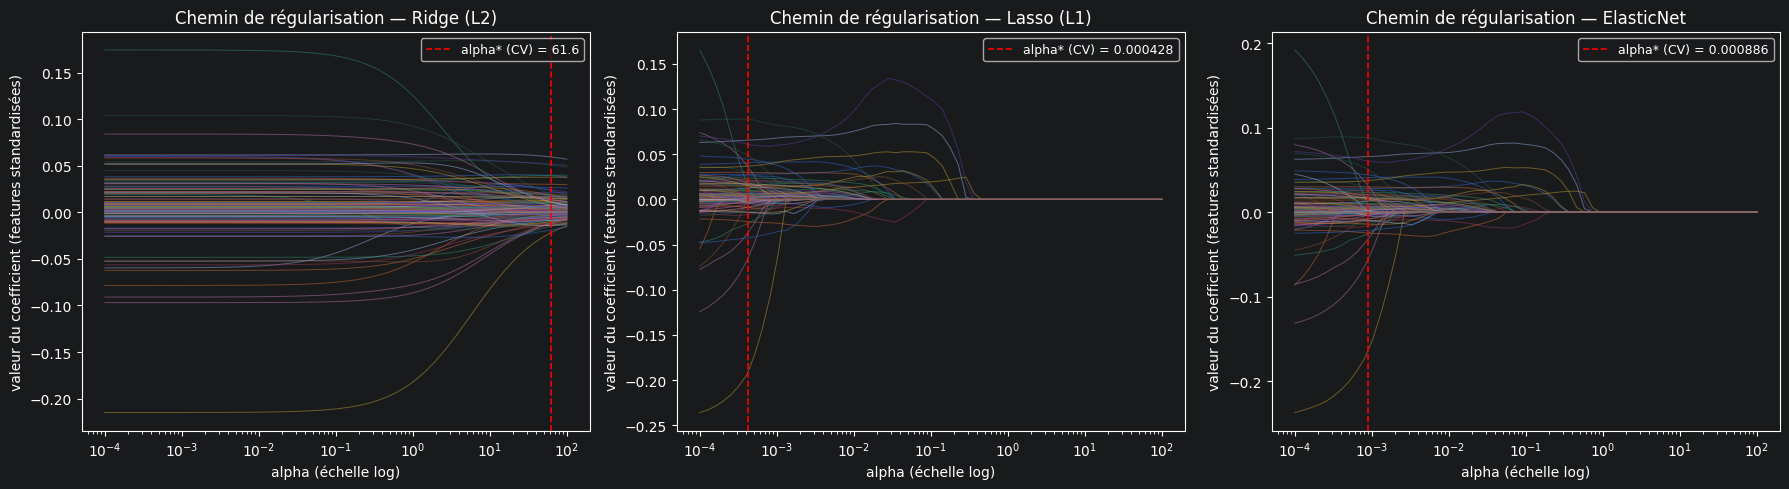

Lasso au alpha* = 0.000428 : 48/129 coefficients exactement nuls (37% des features écartées).


In [9]:
# Chemins de régularisation (diagnostic — ne republie aucun résultat)
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Matrice de design standardisée, ajustée sur le train (clone => aucune dépendance à l'état en place)
_prep = clone(preprocessor_scaled).fit(X_train, y_train_log)
Xtr = _prep.transform(X_train)

alphas = np.logspace(-4, 2, 60)
familles = {
    'Ridge (L2)':   (Ridge(),                                  ridge_alpha),
    'Lasso (L1)':   (Lasso(max_iter=50_000),                   lasso_alpha),
    'ElasticNet':   (ElasticNet(l1_ratio=float(enet_l1), max_iter=50_000), enet_alpha),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nom, (est, a_star)) in zip(axes, familles.items()):
    chemin = []
    for a in alphas:
        est.set_params(alpha=a)
        est.fit(Xtr, y_train_log)
        chemin.append(est.coef_)
    chemin = np.asarray(chemin)  # (n_alphas, n_features)
    ax.plot(alphas, chemin, lw=0.7, alpha=0.5)
    ax.set_xscale('log')
    ax.axvline(a_star, color='red', ls='--', lw=1.2, label=f'alpha* (CV) = {a_star:.3g}')
    ax.set_title(f'Chemin de régularisation — {nom}')
    ax.set_xlabel('alpha (échelle log)')
    ax.set_ylabel('valeur du coefficient (features standardisées)')
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Parcimonie du Lasso au alpha* retenu
_lasso_star = Lasso(alpha=lasso_alpha, max_iter=50_000).fit(Xtr, y_train_log)
_nz = int((_lasso_star.coef_ == 0).sum())
print(f"Lasso au alpha* = {lasso_alpha:.3g} : {_nz}/{len(_lasso_star.coef_)} coefficients exactement nuls "
      f"({100*_nz/len(_lasso_star.coef_):.0f}% des features écartées).")

**À retenir.** Les trois trajectoires illustrent visuellement la différence de nature des pénalités : **Ridge** rétrécit l'ensemble des coefficients de façon continue mais **n'en annule aucun** (il garde toutes les variables, d'où sa sensibilité au bruit des colonnes peu informatives) ; **Lasso** pousse une fraction importante des coefficients **exactement à 0** — c'est une **sélection de variables** intégrée, qui explique à la fois sa compétitivité ici et son choix comme *base learner* du Stacking ; **ElasticNet** se place entre les deux. La ligne rouge montre que la CV retient un `α*` modéré — assez de régularisation pour stabiliser les coefficients face à la **multicolinéarité résiduelle** (cf. §3.5, qui justifie les variables retirées), sans sur-pénaliser. Ce diagnostic ne modifie aucun résultat publié ; il éclaire le *pourquoi* des modèles linéaires comparés en §5.5.2.

## 4.1.5 KNN — k plus proches voisins

### Hypothèses du modèle
- **Aucune hypothèse paramétrique** sur la forme de la relation features↔cible — non-paramétrique.
- Hypothèse implicite : deux points proches dans l'espace des features ont des valeurs `y` proches → la **distance euclidienne** doit avoir un sens.
- Conséquence directe : **toutes les features doivent être à la même échelle**, sans quoi les features de grande amplitude dominent la distance. → `preprocessor_scaled` indispensable.

On balaie `k ∈ [1, 40]` et on choisit le `k` qui maximise le R² en CV.

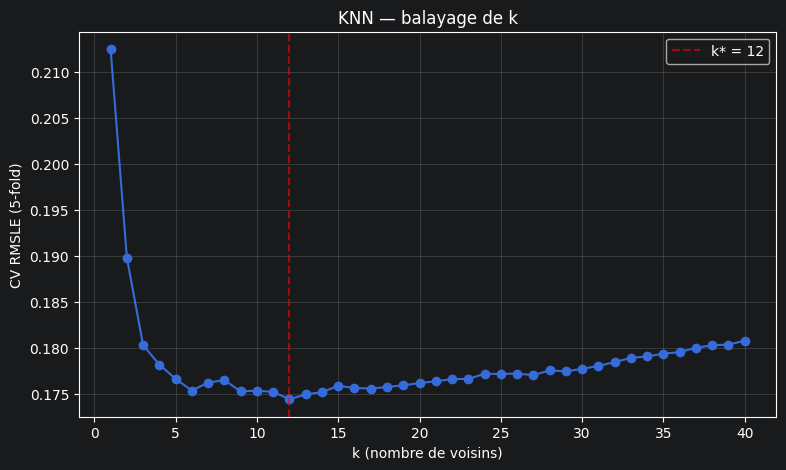

KNN — CV RMSLE: 0.1744   Holdout RMSLE: 0.1867   k*: 12   fit_time (sweep + final): 34.75s


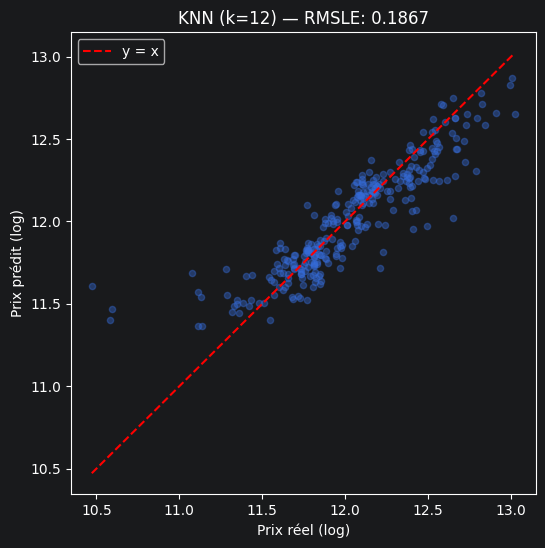

WindowsPath('results/family_scaled.json')

In [10]:
t0 = time.time()
k_range = list(range(1, 41))
knn_cv_scores = []
for k in k_range:
    pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=k))])
    knn_cv_scores.append(-cross_val_score(pipe, X_train, y_train_log, cv=5,
                                          scoring='neg_root_mean_squared_error', n_jobs=-1).mean())

best_k = int(k_range[int(np.argmin(knn_cv_scores))])

plt.figure(figsize=(9, 5))
plt.plot(k_range, knn_cv_scores, marker='o')
plt.axvline(best_k, color='red', ls='--', alpha=0.6, label=f'k* = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('CV RMSLE (5-fold)')
plt.title("KNN — balayage de k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

knn_pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=best_k))])
knn_pipe.fit(X_train, y_train_log)
knn_fit_s = time.time() - t0
knn_pred_log = knn_pipe.predict(X_test)
knn_holdout = rmsle_score(y_test_log, knn_pred_log)
knn_cv = float(min(knn_cv_scores))

print(f"KNN — CV RMSLE: {knn_cv:.4f}   Holdout RMSLE: {knn_holdout:.4f}   k*: {best_k}   fit_time (sweep + final): {knn_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, knn_pred_log, title=f"KNN (k={best_k}) — RMSLE: {knn_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'KNN', cv_rmsle=knn_cv, holdout_rmsle=knn_holdout, fit_time_s=knn_fit_s, params={'k': best_k})

## 4.1.6 MLPRegressor — réseau de neurones tabulaire

### Hypothèses du modèle
- Approximation de fonction lisse par couches denses + activation non-linéaire.
- **Descente de gradient** : très sensible à l'échelle des features (sans normalisation, le gradient explose dans certaines directions et stagne dans d'autres).
- Nécessite une **taille de couche cachée** raisonnable et un **early-stopping** pour éviter le surapprentissage.

On utilise une architecture modeste (1 couche de 64 unités) car notre jeu est petit (≈ 1200 obs train).

Meilleurs hyperparams MLP: {'n_layers': 2, 'n_units_l0': 48, 'n_units_l1': 84, 'learning_rate_init': 0.010029121074080834, 'alpha': 2.655578596010589e-05, 'activation': 'tanh'}
MLP (tuned) — CV RMSLE: 0.1407   Holdout RMSLE: 0.1298   tuning_time: 149.1s


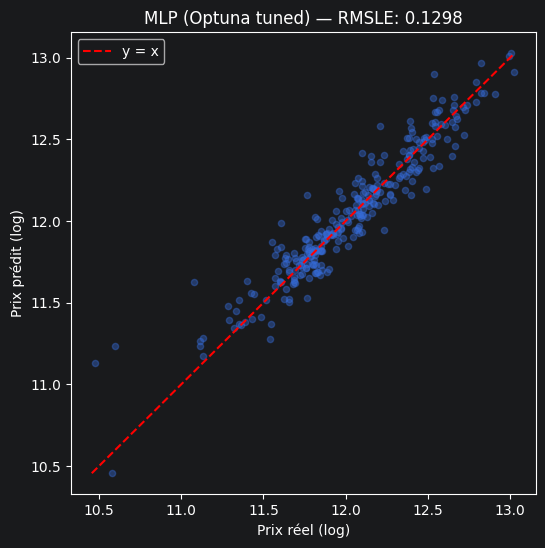

WindowsPath('results/family_scaled.json')

In [11]:
# Tuning Optuna pour MLP (rapide)
# Réduisez n_trials pour debug, augmentez pour production (p.ex. 50-100)
best_mlp_params, best_mlp_pipe, mlp_tuning_time = tune_mlp_pipeline(
    preprocessor_scaled, X_train, y_train_log, n_trials=40, cv=5, random_state=RANDOM_STATE
)
print("Meilleurs hyperparams MLP:", best_mlp_params)
# Évaluer
mlp_pred_log = best_mlp_pipe.predict(X_test)
mlp_holdout = rmsle_score(y_test_log, mlp_pred_log)
mlp_cv = cv_rmsle(best_mlp_pipe, X_train, y_train_log)
print(f"MLP (tuned) — CV RMSLE: {mlp_cv:.4f}   Holdout RMSLE: {mlp_holdout:.4f}   tuning_time: {mlp_tuning_time:.1f}s")
predicted_vs_actual_plot(y_test_log, mlp_pred_log, title=f"MLP (Optuna tuned) — RMSLE: {mlp_holdout:.4f}")
plt.show()
publish_result('scaled', 'MLPRegressor_Optuna', cv_rmsle=mlp_cv, holdout_rmsle=mlp_holdout, fit_time_s=mlp_tuning_time, params=best_mlp_params)

## 4.1.7 SVR — machine à vecteurs de support (régression)

### Hypothèses du modèle
- **Marge ε-insensible** : SVR n'est pénalisé que pour les erreurs dépassant `epsilon`. Les points à l'intérieur du tube ε ne contribuent pas → modèle déterminé par un sous-ensemble de points, les **vecteurs de support** (parcimonie).
- **Noyau RBF** : projette implicitement les features dans un espace de grande dimension → **frontière non-linéaire**. SVR capture donc des interactions que les modèles linéaires de cette famille (OLS/Ridge/Lasso/ElasticNet) ne voient pas — comme MLP, mais sans réseau de neurones.
- **Sensibilité à l'échelle** : le noyau RBF repose sur des **distances** entre points ; une feature de grande amplitude dominerait le noyau. → `preprocessor_scaled` est indispensable (même justification que KNN).
- **Diagnostics vérifiables** : RMSLE en CV et sur le holdout, scatter prédit-vs-réel, résidus vs prédictions, et la **fraction de vecteurs de support** (proxy de complexité — une fraction élevée trahit une frontière très flexible, donc un risque de surapprentissage).
- **Limites** : entraînement et scoring en **O(n²–n³)** — lent à servir en production face au budget de latence du ML Canvas (< 5 s) ; **peu interprétable** (pas de coefficients lisibles comme Lasso) ; performance très sensible au couple `C` / `gamma`, d'où la petite recherche par grille ci-dessous.

**Préprocesseur** : `preprocessor_scaled`.

SVR (Optuna RBF) — CV RMSLE: 0.1140   Holdout RMSLE: 0.1155   tuning_time: 51.28s
  meilleurs hyperparamtres : C=69.50614710097483, gamma=0.00018126852432396546, epsilon=0.03224406376716122
  vecteurs de support : 801/1166 (69%) — lev = frontire complexe / risque de surapprentissage


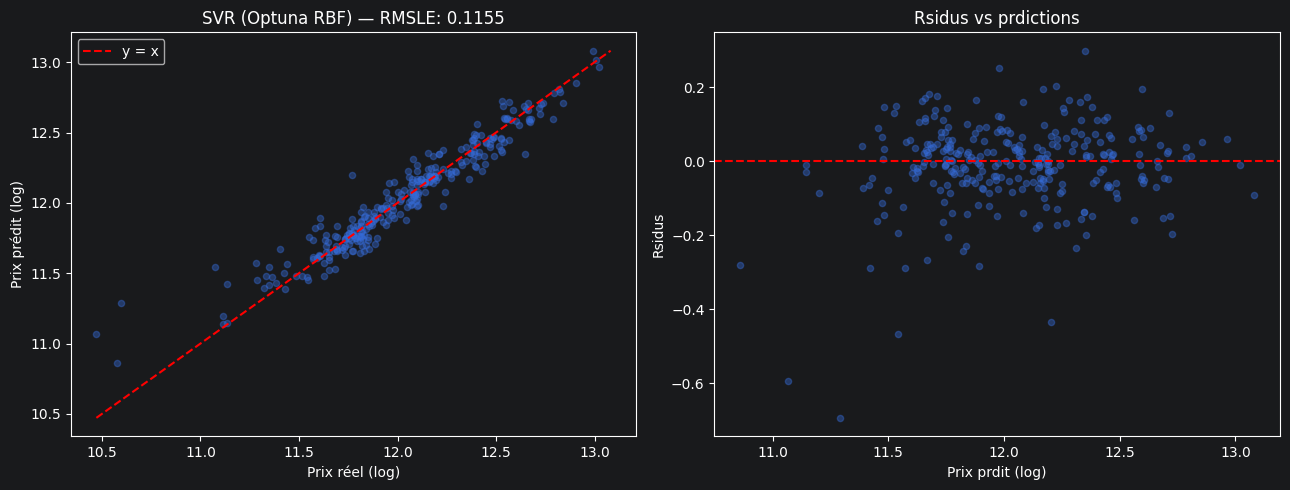

WindowsPath('results/family_scaled.json')

In [12]:
from sklearn.svm import SVR

t0 = time.time()
best_svr_params, svr_pipe, svr_fit_s = tune_svr_pipeline(
    preprocessor_scaled, X_train, y_train_log, n_trials=40, cv=5, random_state=RANDOM_STATE
)
svr_cv = cv_rmsle(svr_pipe, X_train, y_train_log)
svr_pred_log = svr_pipe.predict(X_test)
svr_holdout = rmsle_score(y_test_log, svr_pred_log)
n_sv = int(svr_pipe.named_steps['model'].support_.shape[0])
n_tr = X_train.shape[0]

print(f"SVR (Optuna RBF) — CV RMSLE: {svr_cv:.4f}   Holdout RMSLE: {svr_holdout:.4f}   tuning_time: {svr_fit_s:.2f}s")
print(f"  meilleurs hyperparamtres : C={best_svr_params['C']}, gamma={best_svr_params['gamma']}, epsilon={best_svr_params['epsilon']}")
print(f"  vecteurs de support : {n_sv}/{n_tr} ({100*n_sv/n_tr:.0f}%) — lev = frontire complexe / risque de surapprentissage")

resid = y_test_log.values - svr_pred_log
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
predicted_vs_actual_plot(y_test_log, svr_pred_log, title=f"SVR (Optuna RBF) — RMSLE: {svr_holdout:.4f}", ax=axes[0])
axes[1].scatter(svr_pred_log, resid, alpha=0.4, s=20)
axes[1].axhline(0, color='red', ls='--')
axes[1].set(xlabel='Prix prdit (log)', ylabel='Rsidus', title='Rsidus vs prdictions')
plt.tight_layout()
plt.show()

publish_result(FAMILY, 'SVR_Optuna', cv_rmsle=svr_cv, holdout_rmsle=svr_holdout, fit_time_s=svr_fit_s,
               params={'kernel': 'rbf', 'C': best_svr_params['C'], 'gamma': best_svr_params['gamma'],
                       'epsilon': best_svr_params['epsilon'], 'n_support': n_sv})

**À retenir.** SVR apporte la non-linéarité au sein de la famille « scaled » (comme le MLP, mais sans réseau). Son intérêt dépend de son RMSLE face au coût : entraînement/scoring quadratique et faible interprétabilité le pénalisent en production. On ne le retiendra comme base learner du stacking (`3d`) que s'il décorrèle utilement ses erreurs de celles des autres familles ; sinon il reste un point de comparaison pédagogique du « kernel trick ».

## 4.1.8 Comparaison intra-famille

On compare les RMSLE des modèles sensibles à l'échelle. C'est cette comparaison qui désigne le **champion de famille** qui sera proposé comme base learner dans le notebook `3d_stacking.ipynb`.

Une fois le champion de cette famille identifié, la modélisation se poursuit avec la famille suivante : les **arbres scikit-learn** (`3b`), qui reposent sur des hypothèses radicalement différentes (invariance par transformation monotone, pas de mise à l'échelle).

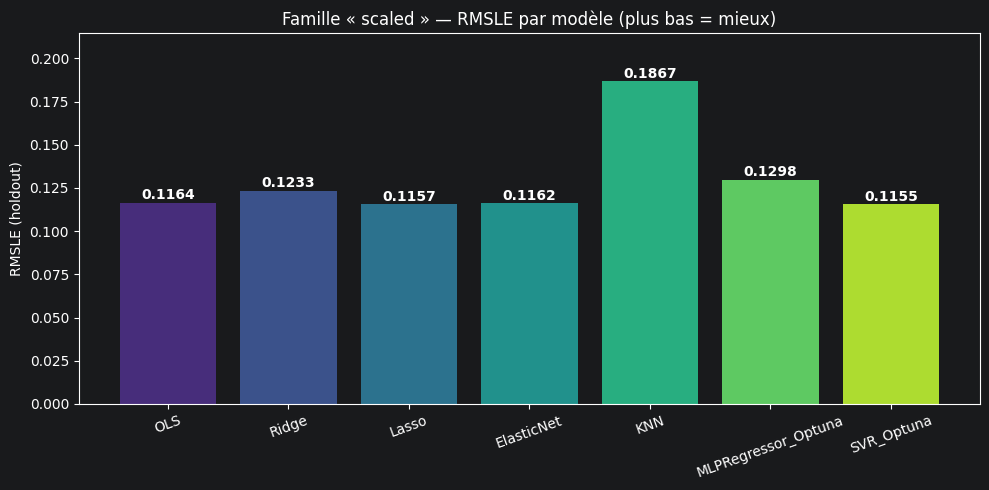

Classement intra-famille (par holdout RMSLE) :


,model,cv_rmsle,holdout_rmsle,fit_time_s
0,OLS,0.120490,0.116354,0.297279
1,Ridge,0.118022,0.123325,0.710114
2,Lasso,0.119210,0.115678,0.348166
3,ElasticNet,0.119088,0.116203,0.753798
4,KNN,0.174406,0.186726,34.746704
5,MLPRegressor_Optuna,0.140726,0.129817,149.088852
6,SVR_Optuna,0.113978,0.115482,51.279495


In [13]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « scaled » — RMSLE par modèle (plus bas = mieux)")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Classement intra-famille (par holdout RMSLE) :")
display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

In [14]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    OLS=ols_pred_log, Ridge=ridge_pred_log, Lasso=lasso_pred_log,
    ElasticNet=enet_pred_log, KNN=knn_pred_log, MLPRegressor=mlp_pred_log, SVR=svr_pred_log,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results\preds_scaled.npz
